In [ ]:
print('welcome')

welcome


In [ ]:
patient_id="oasis male 645"
age=64
mmse_score=0.9
has_dementia=True
print(has_dementia)
print(age)

True
64


In [ ]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [ ]:
patient_id="oasis female 345"
age=28
mmse_score=24
has_dementia=False
print(patient_id)
print(age)
print(mmse_score)
print(has_dementia)

oasis female 345
28
24
False


In [ ]:
patient_name="imran"
age=80
baseline_mmse=26
current_mmse=baseline_mmse-16.25
print(current_mmse)

9.75


In [ ]:
patient_mmse = 35
if patient_mmse >= 24:
 print("not diaganose with dementia")
elif patient_mmse>=10:
  print("diaganose with mild or moderate dementia")
else:
 print("severe dementia")

not diaganose with dementia


In [ ]:
patient_cdr=1
if patient_cdr==0:
 print("healthy")
elif patient_cdr==0.5:
 print("very mild dimentia")
else:
 print("mild dimentia")

mild dimentia


In [ ]:
import pandas as pd
from google.colab import files
uploaded=files.upload()

Saving oasis_cross-sectional.csv to oasis_cross-sectional.csv


In [ ]:
import io
df=pd.read_csv(io.BytesIO(uploaded['oasis_cross-sectional.csv']))
print("data loaded")
df.head()

data loaded


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [ ]:
import pandas as pd
url="https://raw.githubusercontent.com/ParvN/Dementia-classification-on-MRI-dataset/master/oasis_cross-sectional.csv"
clinical_data=pd.read_csv(url)
clinical_data.head()
print(clinical_data.shape)

(436, 12)


In [ ]:
female_cohort= clinical_data[clinical_data['M/F']=='F']
male_cohort= clinical_data[clinical_data['M/F']=='M']
print(f"total isolated female patients are: {female_cohort.shape[0]}")
female_cohort[['Age', 'Educ', 'SES', 'CDR', 'eTIV']].describe()


total isolated female patients are: 268


,Age,Educ,SES,CDR,eTIV
count,268.000000,156.000000,145.000000,156.000000,268.000000
mean,53.369403,3.115385,2.531034,0.259615,1412.656716
std,25.253058,1.279927,1.086886,0.378755,131.596939
min,18.000000,1.000000,1.000000,0.000000,1123.000000
25%,24.000000,2.000000,2.000000,0.000000,1325.500000
50%,58.000000,3.000000,2.000000,0.000000,1407.500000
75%,75.250000,4.000000,3.000000,0.500000,1496.750000
max,96.000000,5.000000,5.000000,2.000000,1794.000000


In [ ]:
severe_dementia= clinical_data[clinical_data ['CDR']== 2.0]
print(severe_dementia.shape[0])

2


In [ ]:
median_cdr=df['CDR'].median()
df['CDR'].fillna(median_cdr, inplace=True)
print(df.isna().sum())

ID         0
M/F        0
Hand       0
Age        0
Educ     201
SES      220
MMSE     201
CDR        0
eTIV       0
nWBV       0
ASF        0
Delay    416
dtype: int64


/tmp/ipykernel_2096/3838912132.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CDR'].fillna(median_cdr, inplace=True)


In [ ]:
mean_cdr=df['CDR'].mean()
df['CDR'].fillna(mean_cdr, inplace=True)
print(df.isna().sum())

ID         0
M/F        0
Hand       0
Age        0
Educ     201
SES      220
MMSE     201
CDR        0
eTIV       0
nWBV       0
ASF        0
Delay    416
dtype: int64


/tmp/ipykernel_2096/3472115357.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CDR'].fillna(mean_cdr, inplace=True)


In [ ]:
median_ses=df['SES'].median()
median_educ=df['Educ'].median()
median_mmse=df['MMSE'].median()
median_delay=df['Delay'].median()
df['SES'].fillna(median_ses, inplace=True)
df['Educ'].fillna(median_educ, inplace=True)
df['MMSE'].fillna(median_mmse, inplace=True)
df['Delay'].fillna(median_delay, inplace=True)
print(df.isna().sum())

ID       0
M/F      0
Hand     0
Age      0
Educ     0
SES      0
MMSE     0
CDR      0
eTIV     0
nWBV     0
ASF      0
Delay    0
dtype: int64


/tmp/ipykernel_2096/3192012893.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SES'].fillna(median_ses, inplace=True)
/tmp/ipykernel_2096/3192012893.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

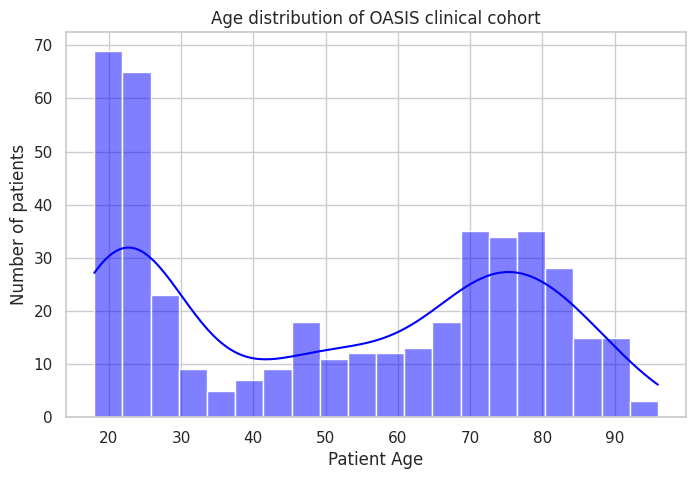

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns. set_theme (style="whitegrid")
plt.figure(figsize= (8,5))
sns. histplot(data=df, x='Age', bins=20, color='blue', kde=True)
plt.title('Age distribution of OASIS clinical cohort')
plt.xlabel('Patient Age')
plt. ylabel('Number of patients')
plt.show()

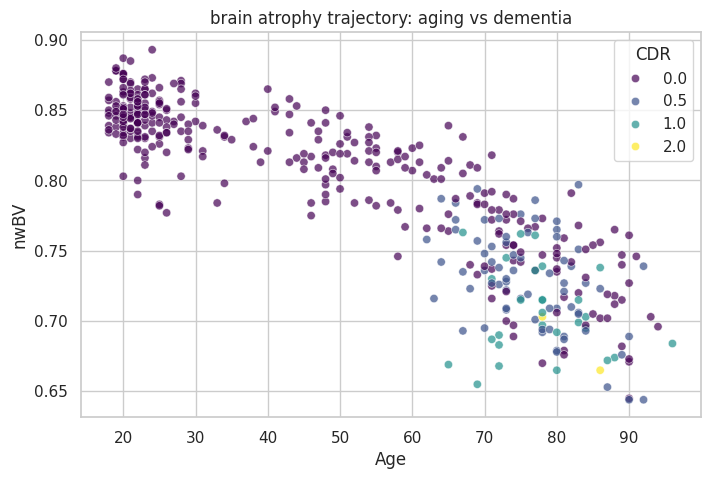

In [ ]:
plt.figure(figsize= (8,5))
sns. scatterplot(data=df, x= 'Age', y= 'nWBV', hue= 'CDR', palette= 'viridis' , alpha=0.7)
plt. title( 'brain atrophy trajectory: aging vs dementia')
plt.xlabel('Age')
plt.ylabel('nwBV')
plt.show()

/tmp/ipykernel_2096/1692712686.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='M/F', y='nWBV', palette= 'Set2')


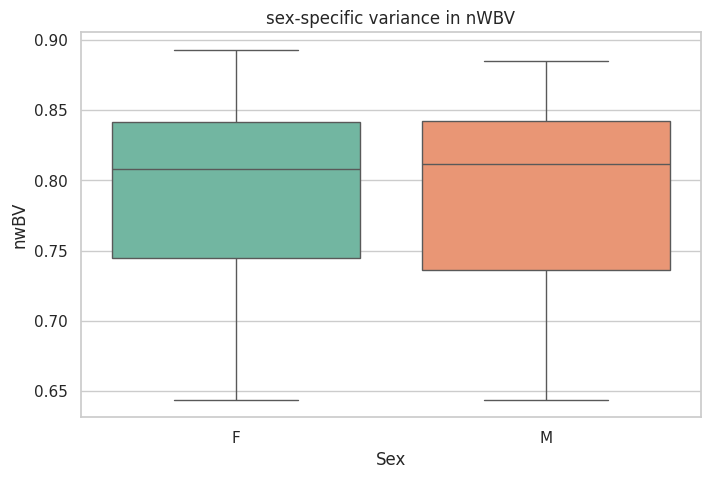

In [ ]:
plt.figure(figsize= (8,5))
sns.boxplot(data=df, x='M/F', y='nWBV', palette= 'Set2')
plt. title('sex-specific variance in nWBV')
plt.xlabel('Sex')
plt.ylabel('nwBV')
plt.show()

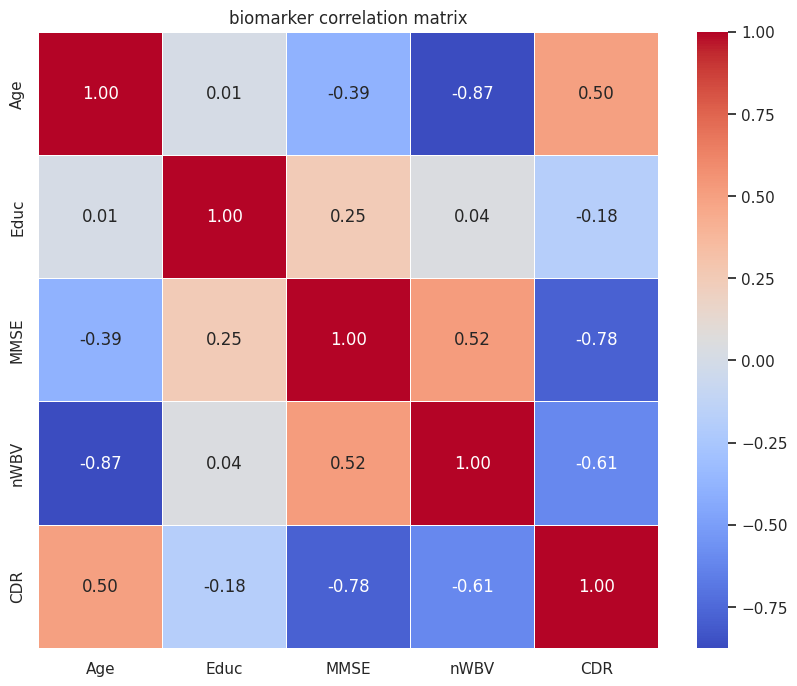

In [ ]:
plt.figure(figsize= (10,8))
clinical_metrics=df[['Age','Educ', 'MMSE', 'nWBV' , 'CDR']]
correlation_matrix= clinical_metrics.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidth=0.5)
plt. title('biomarker correlation matrix')
plt. show()

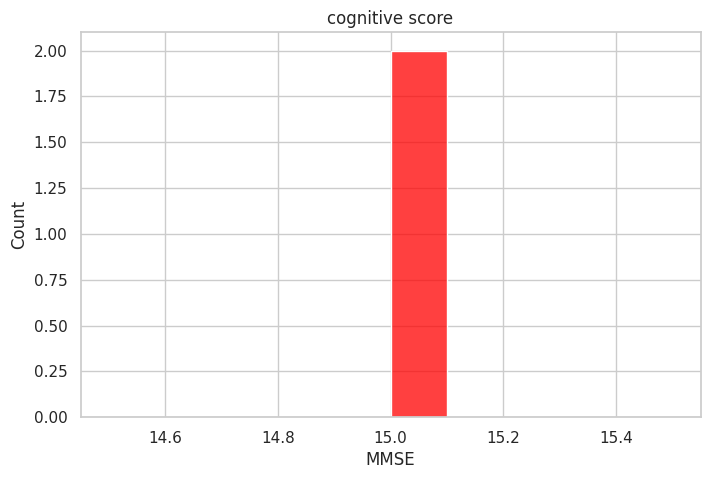

In [ ]:
severe_patients=df[df['CDR']==2.0]
plt.figure(figsize= (8,5))
sns.histplot(data=severe_patients, x= 'MMSE', color='red', bins=10)
plt.title('cognitive score')
plt.show()


In [ ]:
import numpy as np
female_cohort['Diagnosis']= np. where (female_cohort ['CDR']>0,1,0)
print(female_cohort ['Diagnosis']. value_counts())

Diagnosis
0    209
1     59
Name: count, dtype: int64


/tmp/ipykernel_2096/3809061230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  female_cohort['Diagnosis']= np. where (female_cohort ['CDR']>0,1,0)


In [ ]:
x_female=female_cohort.drop(columns=['ID', 'M/F', 'Hand', 'CDR', 'Diagnosis', 'Delay'])
y_female=female_cohort['Diagnosis']
print("feature and target successfully isolated for female cohort")
print(f"the AI will learn from {x_female.shape[1]}biological features")

feature and target successfully isolated for female cohort
the AI will learn from 7biological features


In [ ]:
from sklearn. model_selection import train_test_split
x_train_f, x_test_f, y_train_f, y_test_f=train_test_split(x_female, y_female, test_size=0.20, random_state=42)
print(f"Training AI on {x_train_f. shape[0]} female patients...")
print(f"Holding back {x_test_f. shape[0]} female patients for the final exam.")

Training AI on 214 female patients...
Holding back 54 female patients for the final exam.


In [ ]:
x_train_f = x_train_f.fillna(x_train_f.median())
x_test_f = x_test_f.fillna(x_test_f.median())
print("All hidden blank cells (NaNs) have been successfully filled!")

All hidden blank cells (NaNs) have been successfully filled!


In [ ]:
from sklearn.linear_model import LogisticRegression
female_ai_model=LogisticRegression(max_iter=1000)
female_ai_model.fit(x_train_f, y_train_f)
print("SUCCESS: The Female-Specific AI Model has finished its training phase.")

SUCCESS: The Female-Specific AI Model has finished its training phase.


In [ ]:
from sklearn.metrics import accuracy_score
predictions=female_ai_model.predict(x_test_f)
accuracy=accuracy_score(y_test_f, predictions)
print(f"female cohort baseline AI accuracy: {accuracy*100:.2f}%")

female cohort baseline AI accuracy: 88.89%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
print("initialising AI model...")
rf_female_model=RandomForestClassifier(n_estimators=100, random_state=42)
rf_female_model.fit(x_train_f, y_train_f)
rf_predictions=rf_female_model.predict(x_test_f)
rf_accuracy=accuracy_score(y_test_f, rf_predictions)
print(f"Random Forest AI accuracy female cohort: {rf_accuracy*100:.2f}%")

initialising AI model...
Random Forest AI accuracy female cohort: 88.89%


In [ ]:
import xgboost as xgb
print("initialising xgboost engine")
xgb_female_model=xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_female_model.fit(x_train_f, y_train_f)
xgb_predictions=xgb_female_model.predict(x_test_f)
xgb_accuracy=accuracy_score(y_test_f, xgb_predictions)
print(f"XGBoost AI accuracy female cohort: {xgb_accuracy*100:.2f}%")

initialising xgboost engine
XGBoost AI accuracy female cohort: 88.89%


In [ ]:
from sklearn.metrics import classification_report
print("xgboost diagnostic report")
report=classification_report(y_test_f, xgb_predictions)
target_names=['healthy(0)', 'demented(1)']
print(report)

xgboost diagnostic report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.75      0.75      0.75        12

    accuracy                           0.89        54
   macro avg       0.84      0.84      0.84        54
weighted avg       0.89      0.89      0.89        54



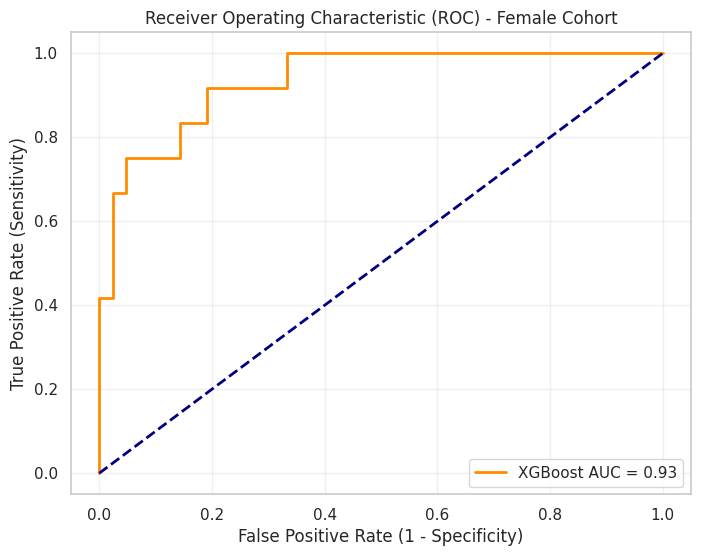

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
xgb_probabilities = xgb_female_model.predict_proba(x_test_f)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_f, xgb_probabilities)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The 50/50 guessing line

plt.title('Receiver Operating Characteristic (ROC) - Female Cohort')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
male_cohort['Diagnosis']= np. where (male_cohort ['CDR']>0,1,0)
print(male_cohort ['Diagnosis']. value_counts())

Diagnosis
0    127
1     41
Name: count, dtype: int64


/tmp/ipykernel_2096/3249237649.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male_cohort['Diagnosis']= np. where (male_cohort ['CDR']>0,1,0)


In [ ]:
x_male=male_cohort.drop(columns=['ID', 'M/F', 'Hand', 'CDR', 'Diagnosis', 'Delay'])
y_male=male_cohort['Diagnosis']
print("feature and target successfully isolated for male cohort")
print(f"the AI will learn from {x_male.shape[1]}biological features")

feature and target successfully isolated for male cohort
the AI will learn from 7biological features


In [ ]:
from sklearn. model_selection import train_test_split
x_train_m, x_test_m, y_train_m, y_test_m=train_test_split(x_male, y_male, test_size=0.20, random_state=42)
print(f"Training AI on {x_train_m. shape[0]} male patients...")
print(f"Holding back {x_test_m. shape[0]} male patients for the final exam.")

Training AI on 134 male patients...
Holding back 34 male patients for the final exam.


In [ ]:
x_train_m = x_train_m.fillna(x_train_m.median())
x_test_m= x_test_m.fillna(x_test_m.median())
print("All hidden blank cells (NaNs) have been successfully filled!")

All hidden blank cells (NaNs) have been successfully filled!


In [ ]:
from sklearn.linear_model import LogisticRegression
male_ai_model=LogisticRegression(max_iter=1000)
male_ai_model.fit(x_train_m, y_train_m)
print("SUCCESS: The male-Specific AI Model has finished its training phase.")

SUCCESS: The male-Specific AI Model has finished its training phase.


In [ ]:
from sklearn.metrics import accuracy_score
predictions=male_ai_model.predict(x_test_m)
accuracy=accuracy_score(y_test_m, predictions)
print(f"male cohort baseline AI accuracy: {accuracy*100:.2f}%")

male cohort baseline AI accuracy: 91.18%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
print("initialising AI model...")
rf_male_model=RandomForestClassifier(n_estimators=100, random_state=42)
rf_male_model.fit(x_train_m, y_train_m)
rf_predictions=rf_male_model.predict(x_test_m)
rf_accuracy=accuracy_score(y_test_m, rf_predictions)
print(f"Random Forest AI accuracy male cohort: {rf_accuracy*100:.2f}%")

initialising AI model...
Random Forest AI accuracy male cohort: 82.35%


In [ ]:
import xgboost as xgb
print("initialising xgboost engine")
xgb_male_model=xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_male_model.fit(x_train_m, y_train_m)
xgb_predictions=xgb_male_model.predict(x_test_m)
xgb_accuracy=accuracy_score(y_test_m, xgb_predictions)
print(f"XGBoost AI accuracy male cohort: {xgb_accuracy*100:.2f}%")

initialising xgboost engine
XGBoost AI accuracy male cohort: 82.35%


In [ ]:
from sklearn.metrics import classification_report
print("xgboost diagnostic report")
report=classification_report(y_test_m, xgb_predictions)
target_names=['healthy(0)', 'demented(1)']
print(report)

xgboost diagnostic report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        26
           1       0.62      0.62      0.62         8

    accuracy                           0.82        34
   macro avg       0.75      0.75      0.75        34
weighted avg       0.82      0.82      0.82        34



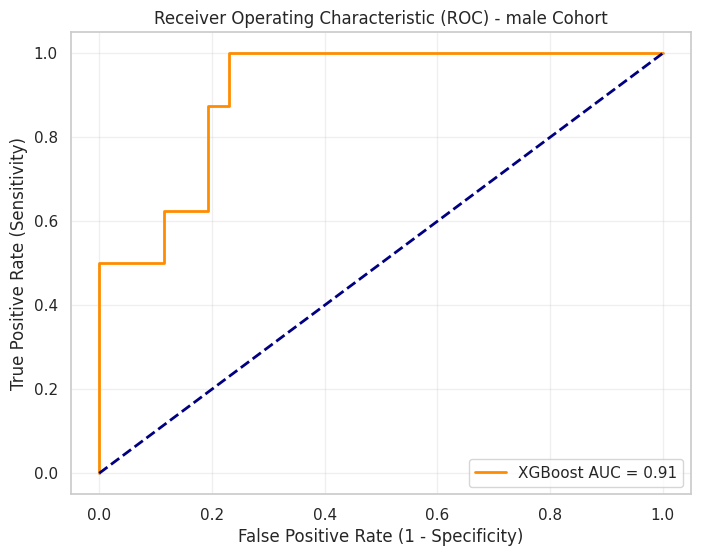

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
xgb_probabilities = xgb_male_model.predict_proba(x_test_m)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_m, xgb_probabilities)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The 50/50 guessing line

plt.title('Receiver Operating Characteristic (ROC) - male Cohort')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
!pip install shap
import shap
shap.initjs()

print("SHAP Game Theory Library Successfully Installed.")

SHAP Game Theory Library Successfully Installed.


In [ ]:
print("Cracking open the XGBoost Black Box...")
explainer = shap.TreeExplainer(xgb_female_model)
shap_values = explainer.shap_values(x_test_f)
print("Biomarker weights successfully extracted! Ready for visualization.")

Cracking open the XGBoost Black Box...
Biomarker weights successfully extracted! Ready for visualization.


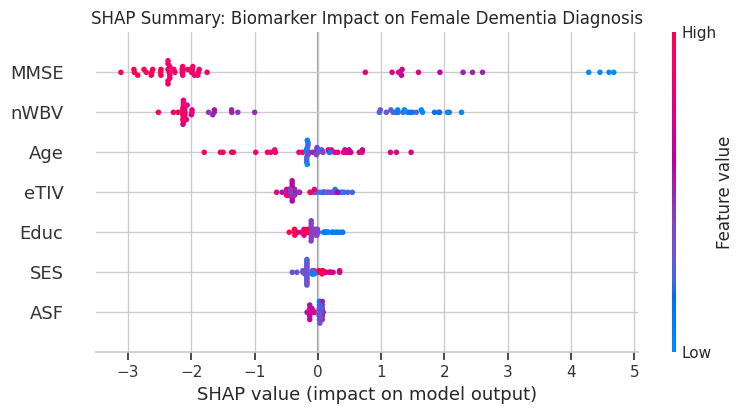

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary: Biomarker Impact on Female Dementia Diagnosis")
shap.summary_plot(shap_values, x_test_f, show=False)

plt.tight_layout()
plt.show()

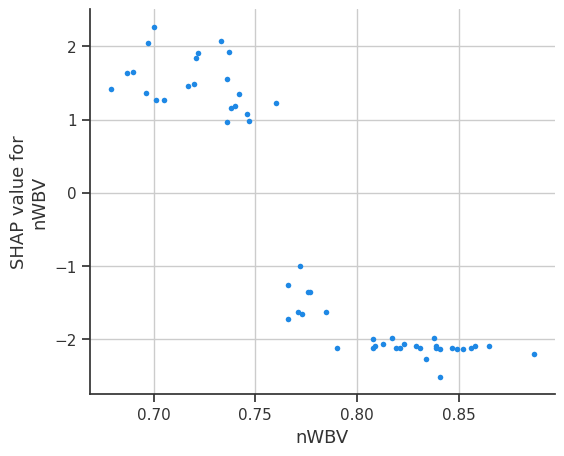

In [ ]:
shap.dependence_plot("nWBV", shap_values, x_test_f, interaction_index=None)

In [ ]:
print("Cracking open the XGBoost Black Box...")
explainer = shap.TreeExplainer(xgb_male_model)
shap_values = explainer.shap_values(x_test_m)
print("Biomarker weights successfully extracted! Ready for visualization.")

Cracking open the XGBoost Black Box...
Biomarker weights successfully extracted! Ready for visualization.


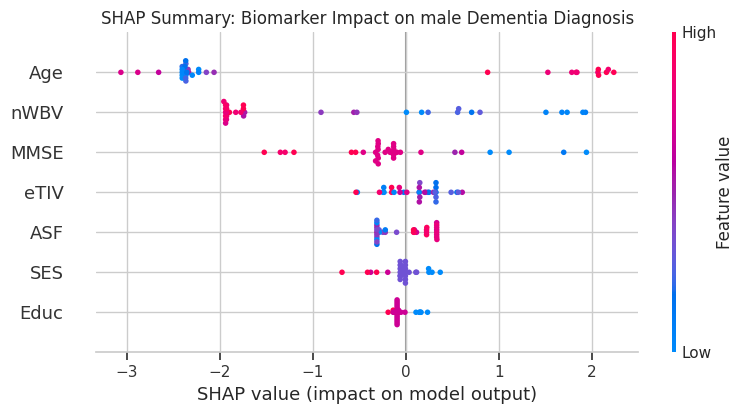

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary: Biomarker Impact on male Dementia Diagnosis")
shap.summary_plot(shap_values, x_test_m, show=False)

plt.tight_layout()
plt.show()

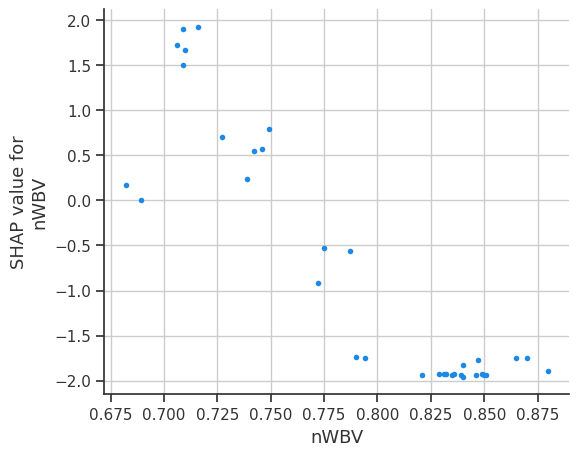

In [ ]:
shap.dependence_plot("nWBV", shap_values, x_test_m, interaction_index=None)

In [ ]:

import xgboost as xgb
from sklearn.model_selection import GridSearchCV

print("Initializing Grid Search to find optimal AI parameters for both cohorts...")

parameter_grid = {
    'max_depth': [3, 5, 7],           # How deep the AI's decision trees can grow
    'learning_rate': [0.01, 0.05, 0.1], # How aggressively the AI corrects its mistakes
    'n_estimators': [100, 200, 300]   # The total number of doctors (trees) on the board
}

# 2. Optimize the FEMALE Model
print("Optimizing Female Cohort AI...")
base_xgb_f = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_search_f = GridSearchCV(estimator=base_xgb_f, param_grid=parameter_grid, scoring='roc_auc', cv=5)
grid_search_f.fit(x_train_f, y_train_f)
best_female_model = grid_search_f.best_estimator_ # Save the absolute smartest version

# 3. Optimize the MALE Model
print("Optimizing Male Cohort AI...")
base_xgb_m = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_search_m = GridSearchCV(estimator=base_xgb_m, param_grid=parameter_grid, scoring='roc_auc', cv=5)
grid_search_m.fit(x_train_m, y_train_m)
best_male_model = grid_search_m.best_estimator_

print("\n--- OPTIMIZATION COMPLETE ---")
print(f"Best Female Settings: {grid_search_f.best_params_} | AUC: {grid_search_f.best_score_:.3f}")
print(f"Best Male Settings:   {grid_search_m.best_params_} | AUC: {grid_search_m.best_score_:.3f}")

Initializing Grid Search to find optimal AI parameters for both cohorts...
Optimizing Female Cohort AI...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:58:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:58:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:58:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:58:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Optimizing Male Cohort AI...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:58:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:58:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:58:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:58:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


--- OPTIMIZATION COMPLETE ---
Best Female Settings: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300} | AUC: 0.978
Best Male Settings:   {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300} | AUC: 0.930


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:59:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:59:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
print("Executing 5-Fold Cross-Validation on Optimized Models...")
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# 1. Validate Female Model
cv_scores_f = cross_val_score(best_female_model, x_female, y_female, cv=cv_strategy, scoring='roc_auc')
# 2. Validate Male Model
cv_scores_m = cross_val_score(best_male_model, x_male, y_male, cv=cv_strategy, scoring='roc_auc')
print("\n--- VALIDATION RESULTS ---")
print(f"Female Cohort True AUC: {cv_scores_f.mean():.3f} (± {cv_scores_f.std():.3f})")
print(f"Male Cohort True AUC:   {cv_scores_m.mean():.3f} (± {cv_scores_m.std():.3f})")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:59:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Executing 5-Fold Cross-Validation on Optimized Models...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:59:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:59:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:59:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:59:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


--- VALIDATION RESULTS ---
Female Cohort True AUC: 0.973 (± 0.008)
Male Cohort True AUC:   0.943 (± 0.017)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:59:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Extracting Game-Theory Biomarker Hierarchies...


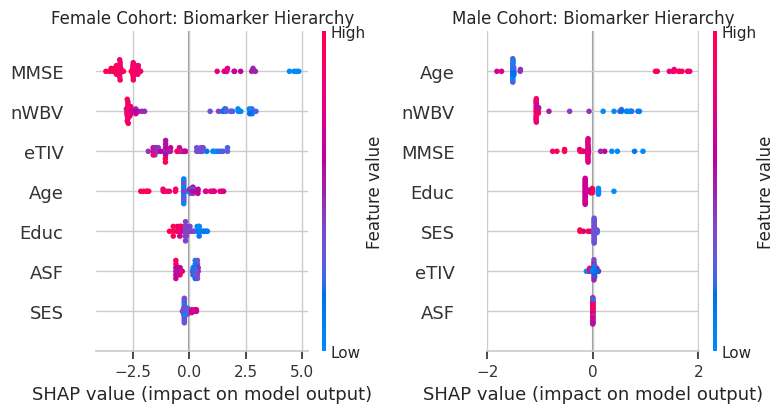

High-Resolution TIFF image saved for manuscript submission.


In [ ]:

import shap
import matplotlib.pyplot as plt

print("Extracting Game-Theory Biomarker Hierarchies...")

# 1. Interrogate both optimized brains
explainer_F = shap.TreeExplainer(best_female_model)
shap_values_F = explainer_F.shap_values(x_test_f)

explainer_M = shap.TreeExplainer(best_male_model)
shap_values_M = explainer_M.shap_values(x_test_m)

# 2. Draw the Side-by-Side Publication Graph
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Female Plot
plt.subplot(1, 2, 1)
plt.title("Female Cohort: Biomarker Hierarchy")
shap.summary_plot(shap_values_F, x_test_f, show=False)

# Male Plot
plt.subplot(1, 2, 2)
plt.title("Male Cohort: Biomarker Hierarchy")
shap.summary_plot(shap_values_M, x_test_m, show=False)

# Save the high-resolution image for the Scopus paper
plt.tight_layout()
plt.savefig('Comparative_SHAP_Analysis.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.show()

print("High-Resolution TIFF image saved for manuscript submission.")

In [ ]:
# ==========================================
# PHASE 4: EXPORTING THE ALGORITHMS
# ==========================================
import joblib
from google.colab import files

print("Freezing AI matrices for clinical deployment...")

# 1. Save the models as .pkl (Pickle) files
joblib.dump(best_female_model, 'OASIS_Female_XGBoost_Optimized.pkl')
joblib.dump(best_male_model, 'OASIS_Male_XGBoost_Optimized.pkl')

# 2. Trigger the download to the student's actual computer
files.download('OASIS_Female_XGBoost_Optimized.pkl')
files.download('OASIS_Male_XGBoost_Optimized.pkl')

print("SUCCESS: AI Models have been permanently saved.")

Freezing AI matrices for clinical deployment...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

SUCCESS: AI Models have been permanently saved.


In [ ]:
# ==========================================
# PHASE 5: COMPREHENSIVE ALGORITHMIC BENCHMARKING
# ==========================================
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, confusion_matrix, f1_score

print("Initializing Benchmarking Protocol for Top-Tier Journal Submission...\n")

# 1. Define a function to extract all clinical metrics
def calculate_clinical_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    sens = recall_score(y_true, y_pred) # Sensitivity / True Positive Rate

    # Calculate Specificity from the Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp) # True Negative Rate

    f1 = f1_score(y_true, y_pred)

    # Return rounded to 3 decimal places for academic reporting
    return [round(acc, 3), round(auc, 3), round(sens, 3), round(spec, 3), round(f1, 3)]

# 2. Define the baseline competitors
# Note: LightGBM is the direct rival to XGBoost in modern data science.
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

# 3. Create a function to evaluate all models for a specific cohort
def evaluate_cohort(cohort_name, x_train, y_train, x_test, y_test, optimized_xgb_model):
    results = []

    # Train and evaluate baseline models
    for model_name, model in baseline_models.items():
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        y_prob = model.predict_proba(x_test)[:, 1]

        metrics = calculate_clinical_metrics(y_test, y_pred, y_prob)
        results.append([model_name] + metrics)

    # Evaluate YOUR Optimized Champion Model (XGBoost)
    xgb_pred = optimized_xgb_model.predict(x_test)
    xgb_prob = optimized_xgb_model.predict_proba(x_test)[:, 1]
    xgb_metrics = calculate_clinical_metrics(y_test, xgb_pred, xgb_prob)
    results.append(["XGBoost (Optimized)"] + xgb_metrics)

    # Format into a beautiful Pandas DataFrame
    columns = ["Algorithm", "Accuracy", "ROC-AUC", "Sensitivity", "Specificity", "F1-Score"]
    df_results = pd.DataFrame(results, columns=columns)

    print(f"--- BENCHMARKING RESULTS: {cohort_name.upper()} COHORT ---")
    display(df_results) # Use display() in Colab for a cleanly formatted table
    print("\n")
    return df_results

# 4. Execute the Benchmarking
# (Ensure x_train_f, y_train_f, best_female_model, etc., are already loaded in your environment)
df_female_benchmark = evaluate_cohort("Female", x_train_f, y_train_f, x_test_f, y_test_f, best_female_model)
df_male_benchmark = evaluate_cohort("Male", x_train_m, y_train_m, x_test_m, y_test_m, best_male_model)

# Optional: Save tables to CSV for easy copy-pasting into Microsoft Word or LaTeX
df_female_benchmark.to_csv("Female_Cohort_Benchmarking.csv", index=False)
df_male_benchmark.to_csv("Male_Cohort_Benchmarking.csv", index=False)
print("Benchmarking tables successfully saved to CSV!")

Initializing Benchmarking Protocol for Top-Tier Journal Submission...

--- BENCHMARKING RESULTS: FEMALE COHORT ---


,Algorithm,Accuracy,ROC-AUC,Sensitivity,Specificity,F1-Score
0,Logistic Regression,0.889,0.935,0.667,0.952,0.727
1,SVC (Linear),0.889,0.901,0.667,0.952,0.727
2,Random Forest,0.889,0.944,0.667,0.952,0.727
3,LightGBM,0.870,0.915,0.583,0.952,0.667
4,XGBoost (Optimized),0.870,0.929,0.667,0.929,0.696




--- BENCHMARKING RESULTS: MALE COHORT ---


,Algorithm,Accuracy,ROC-AUC,Sensitivity,Specificity,F1-Score
0,Logistic Regression,0.912,0.962,0.875,0.923,0.824
1,SVC (Linear),0.941,0.966,0.875,0.962,0.875
2,Random Forest,0.824,0.913,0.750,0.846,0.667
3,LightGBM,0.824,0.947,0.750,0.846,0.667
4,XGBoost (Optimized),0.765,0.906,0.625,0.808,0.556




Benchmarking tables successfully saved to CSV!


Generating Publication-Quality SHAP Interaction Plots...


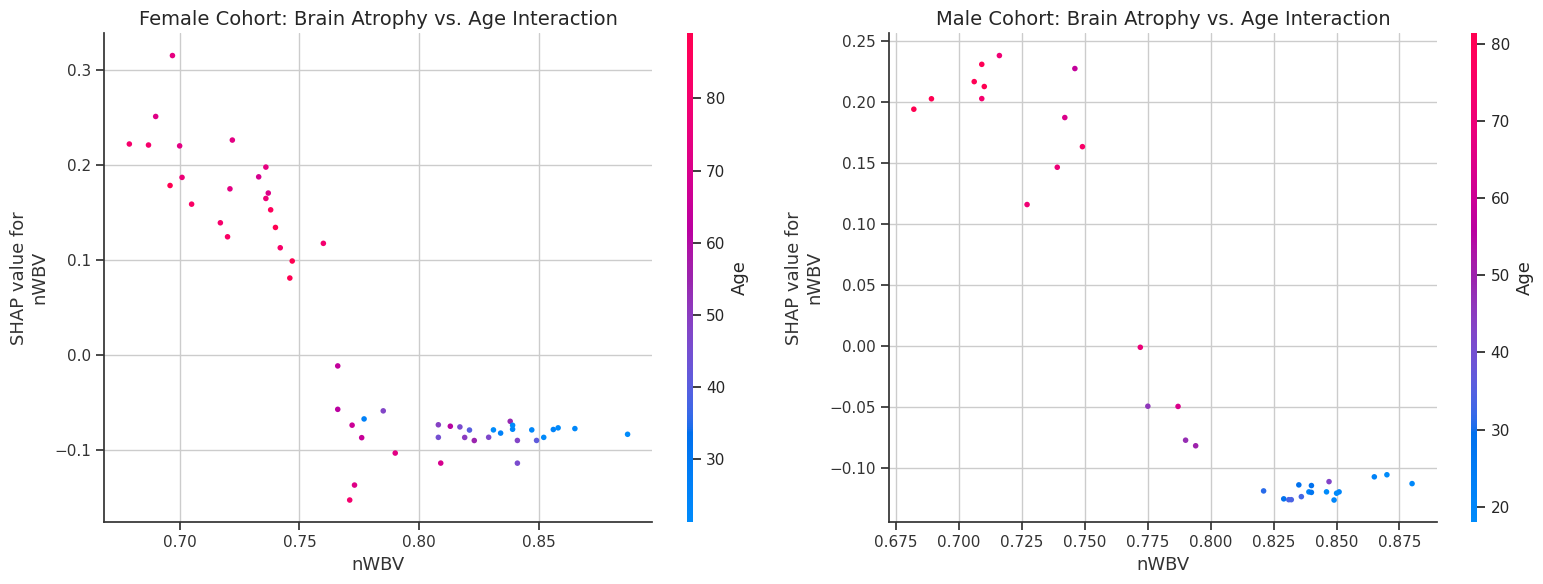

Success! High-resolution interaction TIFF saved.


In [ ]:
import shap
import matplotlib.pyplot as plt

print("Generating Publication-Quality SHAP Interaction Plots...")

# 1. Safely extract 2D SHAP values for the FEMALE cohort (Class 1: Demented)
shap_values_f_raw = explainer_F.shap_values(x_test_f)
if isinstance(shap_values_f_raw, list):
    shap_vals_F = shap_values_f_raw[1]               # If it's a list, grab class 1
elif len(shap_values_f_raw.shape) == 3:
    shap_vals_F = shap_values_f_raw[:, :, 1]         # If it's a 3D array, slice class 1
else:
    shap_vals_F = shap_values_f_raw                  # If it's already 2D (like XGBoost)

# 2. Safely extract 2D SHAP values for the MALE cohort (Class 1: Demented)
shap_values_m_raw = explainer_M.shap_values(x_test_m)
if isinstance(shap_values_m_raw, list):
    shap_vals_M = shap_values_m_raw[1]
elif len(shap_values_m_raw.shape) == 3:
    shap_vals_M = shap_values_m_raw[:, :, 1]
else:
    shap_vals_M = shap_values_m_raw

# 3. Create the canvas for the side-by-side paper figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4. FEMALE INTERACTION PLOT: nWBV vs Age
plt.subplot(1, 2, 1)
plt.title("Female Cohort: Brain Atrophy vs. Age Interaction", fontsize=14)
shap.dependence_plot(
    "nWBV",
    shap_vals_F,
    x_test_f,
    interaction_index="Age",
    ax=axes[0],
    show=False
)

# 5. MALE INTERACTION PLOT: nWBV vs Age
plt.subplot(1, 2, 2)
plt.title("Male Cohort: Brain Atrophy vs. Age Interaction", fontsize=14)
shap.dependence_plot(
    "nWBV",
    shap_vals_M,
    x_test_m,
    interaction_index="Age",
    ax=axes[1],
    show=False
)

# 6. Save and Display
plt.tight_layout()
plt.savefig('SHAP_Dependence_Interaction.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.show()

print("Success! High-resolution interaction TIFF saved.")

Generating Clinical Standards for High-Impact Journal Submission...

--- TABLE 1: BASELINE POPULATION DEMOGRAPHICS ---


,Biomarker,Female Cohort (Mean ± SD),Male Cohort (Mean ± SD),p-value
0,Age,53.37 ± 25.25,48.15 ± 25.04,0.0354
1,Educ,3.12 ± 1.28,3.30 ± 1.37,0.3107
2,SES,2.53 ± 1.09,2.41 ± 1.19,0.4659
3,MMSE,27.12 ± 3.84,26.96 ± 3.41,0.7557
4,nWBV,0.79 ± 0.06,0.79 ± 0.06,0.9524
5,eTIV,1412.66 ± 131.60,1592.41 ± 134.05,<0.0001


Table 1 successfully saved to CSV!

--- 95% CONFIDENCE INTERVALS FOR AI DIAGNOSTICS ---
Female Random Forest AUC: 0.944 (95% CI: 0.857 - 0.996)
Male Random Forest AUC:   0.913 (95% CI: 0.793 - 0.990)

--- GENERATING CLINICAL CONFUSION MATRICES ---


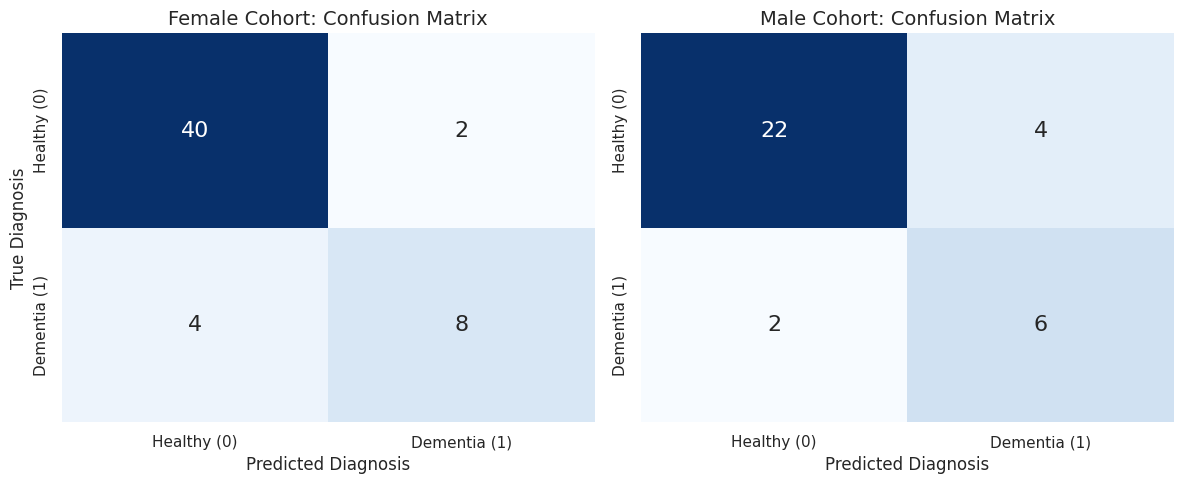

Success! High-resolution Confusion Matrices saved as TIFF.


In [ ]:
# ==========================================
# PHASE 6: CLINICAL STANDARDS & RIGOR
# ==========================================
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.utils import resample

print("Generating Clinical Standards for High-Impact Journal Submission...\n")

# ---------------------------------------------------------
# 1. GENERATING "TABLE 1: BASELINE CHARACTERISTICS"
# ---------------------------------------------------------
print("--- TABLE 1: BASELINE POPULATION DEMOGRAPHICS ---")
features_for_table = ['Age', 'Educ', 'SES', 'MMSE', 'nWBV', 'eTIV']
table_data = []

for feature in features_for_table:
    # Drop NaNs just for the statistical baseline calculation
    f_data = female_cohort[feature].dropna()
    m_data = male_cohort[feature].dropna()

    f_mean, f_std = f_data.mean(), f_data.std()
    m_mean, m_std = m_data.mean(), m_data.std()

    # Perform a statistical T-test to get the p-value
    t_stat, p_val = ttest_ind(f_data, m_data, equal_var=False)

    table_data.append({
        'Biomarker': feature,
        'Female Cohort (Mean ± SD)': f"{f_mean:.2f} ± {f_std:.2f}",
        'Male Cohort (Mean ± SD)': f"{m_mean:.2f} ± {m_std:.2f}",
        'p-value': f"{p_val:.4f}" if p_val >= 0.0001 else "<0.0001" # Format highly significant values
    })

df_table1 = pd.DataFrame(table_data)
display(df_table1)
df_table1.to_csv("Table_1_Baseline_Characteristics.csv", index=False)
print("Table 1 successfully saved to CSV!\n")


# ---------------------------------------------------------
# 2. CALCULATING 95% CONFIDENCE INTERVALS (BOOTSTRAPPING)
# ---------------------------------------------------------
print("--- 95% CONFIDENCE INTERVALS FOR AI DIAGNOSTICS ---")

def calculate_auc_with_ci(y_true, y_pred_prob, n_bootstraps=1000):
    y_true = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    bootstrapped_scores = []

    for i in range(n_bootstraps):
        # Bootstrap by randomly resampling the data 1000 times
        indices = resample(range(len(y_pred_prob)))
        if len(np.unique(y_true[indices])) < 2:
            continue # Skip if a sample accidentally only gets 1 class

        score = roc_auc_score(y_true[indices], y_pred_prob[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()

    # 95% CI is the 2.5th and 97.5th percentiles of the 1000 tests
    ci_lower = np.percentile(sorted_scores, 2.5)
    ci_upper = np.percentile(sorted_scores, 97.5)
    return ci_lower, ci_upper

# We are using your champion Random Forest models here
rf_prob_f = rf_female_model.predict_proba(x_test_f)[:, 1]
rf_pred_f = rf_female_model.predict(x_test_f)
auc_f = roc_auc_score(y_test_f, rf_prob_f)
ci_lower_f, ci_upper_f = calculate_auc_with_ci(y_test_f, rf_prob_f)

rf_prob_m = rf_male_model.predict_proba(x_test_m)[:, 1]
rf_pred_m = rf_male_model.predict(x_test_m)
auc_m = roc_auc_score(y_test_m, rf_prob_m)
ci_lower_m, ci_upper_m = calculate_auc_with_ci(y_test_m, rf_prob_m)

print(f"Female Random Forest AUC: {auc_f:.3f} (95% CI: {ci_lower_f:.3f} - {ci_upper_f:.3f})")
print(f"Male Random Forest AUC:   {auc_m:.3f} (95% CI: {ci_lower_m:.3f} - {ci_upper_m:.3f})\n")


# ---------------------------------------------------------
# 3. PLOTTING PUBLICATION-QUALITY CONFUSION MATRICES
# ---------------------------------------------------------
print("--- GENERATING CLINICAL CONFUSION MATRICES ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Female Confusion Matrix
cm_f = confusion_matrix(y_test_f, rf_pred_f)
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Healthy (0)', 'Dementia (1)'],
            yticklabels=['Healthy (0)', 'Dementia (1)'],
            annot_kws={"size": 16})
axes[0].set_title('Female Cohort: Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted Diagnosis', fontsize=12)
axes[0].set_ylabel('True Diagnosis', fontsize=12)

# Male Confusion Matrix
cm_m = confusion_matrix(y_test_m, rf_pred_m)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Healthy (0)', 'Dementia (1)'],
            yticklabels=['Healthy (0)', 'Dementia (1)'],
            annot_kws={"size": 16})
axes[1].set_title('Male Cohort: Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted Diagnosis', fontsize=12)

plt.tight_layout()
plt.savefig('Clinical_Confusion_Matrices.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.show()

print("Success! High-resolution Confusion Matrices saved as TIFF.")